## Create the element objects encoding the IVU RW Impedances

### Imports

In [ ]:
import os
import sys
import importlib
import warnings

import numpy as np

import pycolleff.impedances as imp
import pycolleff.materials_params as mat_par

warnings.filterwarnings('ignore')

utils = importlib.import_module('utils')

### IVU Parameters

Model the IVU chamber as a flat chamber with layers:

- 0: $\,$ Vacuum $\,$ ($r_0$ = gap/2 - 0.05 $mm$ - 0.02 $mm$)
- 1: $\;$ Cu $\:$ $\:$ $\:$ $\:$ $\:$ $\:$ ($r_1$ = gap/2 - 0.05 $mm$)
- 2: $\;$ Ni $\:$ $\:$ $\:$ $\:$ $\:$ $\:$ ($r_2$ = gap/2)
- 2: $\;$ NdFe  $\:$ $\:$ $\:$ ($r_3$ = $\infty$)

_PS: Gap is the distance between magnets_

In [ ]:
cu_cond = mat_par.cu_cond
cu_rel_time = mat_par.cu_rel_time
cu_thick = 0.05e-3  # [m]

ni_cond = 1.43e7  # [S/m]
ni_rel_time = 5.5e-15  # [s]
ni_thick = 0.02e-3  # [m]

ndfe_cond = mat_par.ndfe_cond
ndfe_mur = mat_par.ndfe_mur

gaps = [4.3e-3, 6.4e-3, 8.5e-3]  # [m]

length = 2.01399  # [m]
energy = 3e9  # [eV]

epb = np.array([1, 1, 1, 1])
mub = np.array([1, 1, 1, ndfe_mur])
ange = np.array([0, 0, 0, 0])
angm = np.array([0, 0, 0, 0])
sigmadc = np.array([0, cu_cond, ni_cond, ndfe_cond])  # [S]
tau = np.array([0, cu_rel_time, ni_rel_time, 0], dtype=float)  # [s]

radii = [
    gap / 2 + np.array([-(cu_thick + ni_thick), -cu_thick, 0]) for gap in gaps
]  # [m]

#### Get ang_freq, epr, mur

In [ ]:
ang_freqs = [
    imp.get_default_reswall_w(radius=radius[0], energy=energy)
    for radius in radii
]

eprs_murs = [
    imp.prepare_inputs_epr_mur(ang_freq, epb, mub, ange, angm, sigmadc, tau)
    for ang_freq in ang_freqs
]

eprs, murs = zip(*eprs_murs)

eprs = list(eprs)
murs = list(murs)

### Create elements

In [ ]:
el_names = [
    'IVU RW Gap 4p3',
    'IVU RW Gap 8p4',
    'IVU RW Gap 10p5',
]

els = [imp.Element(el_name) for el_name in el_names]

#### Calculate Impedances

In [ ]:
for i, el in enumerate(els):
    Zll, Zdx, Zdy, Zqx, Zqy = imp.multilayer_flat_chamber(
        ang_freqs[i], length, energy, eprs[i], murs[i], radii[i], precision=70
    )

    Zll, ang_freqs[i] = imp.get_impedance_for_negative_w(
        Zll, ang_freqs[i], impedance_type='ll'
    )

    el.ang_freq = ang_freqs[i]
    el.Zll = Zll
    el.Zdx = imp.get_impedance_for_negative_w(Zdx, impedance_type='t')
    el.Zdy = imp.get_impedance_for_negative_w(Zdy, impedance_type='t')
    el.Zqx = imp.get_impedance_for_negative_w(Zqx, impedance_type='t')
    el.Zqy = imp.get_impedance_for_negative_w(Zqy, impedance_type='t')

0000/0401 -> freq =      0.1 Hz,   converged = yes,   n_evals = 0483  (ET: 1.35 s)
0001/0401 -> freq =     0.11 Hz,   converged = yes,   n_evals = 0483  (ET: 1.22 s)
0002/0401 -> freq =     0.12 Hz,   converged = yes,   n_evals = 0483  (ET: 1.17 s)
0003/0401 -> freq =     0.13 Hz,   converged = yes,   n_evals = 0483  (ET: 1.18 s)
0004/0401 -> freq =     0.15 Hz,   converged = yes,   n_evals = 0525  (ET: 1.18 s)
0005/0401 -> freq =     0.16 Hz,   converged = yes,   n_evals = 0525  (ET: 1.16 s)
0006/0401 -> freq =     0.18 Hz,   converged = yes,   n_evals = 0525  (ET: 1.15 s)
0007/0401 -> freq =      0.2 Hz,   converged = yes,   n_evals = 0525  (ET: 1.14 s)
0008/0401 -> freq =     0.22 Hz,   converged = yes,   n_evals = 0525  (ET: 1.16 s)
0009/0401 -> freq =     0.24 Hz,   converged = yes,   n_evals = 0567  (ET: 1.23 s)
0010/0401 -> freq =     0.27 Hz,   converged = yes,   n_evals = 0525  (ET: 1.18 s)
0011/0401 -> freq =     0.29 Hz,   converged = yes,   n_evals = 0525  (ET: 1.19 s)
0012

#### Calculate Wakes from Impedances

In [103]:
for el in els:
    idx = el.ang_freq > 0
    wp = el.ang_freq[idx]
    spos = imp.DEFAULT_SPOS_RW.copy()
    el.pos = spos
    el.Wll = imp.from_impedance_to_wake(spos, wp, el.Zll[idx], plane='long')
    el.Wdx = imp.from_impedance_to_wake(spos, wp, el.Zdx[idx], plane='trans')
    el.Wdy = imp.from_impedance_to_wake(spos, wp, el.Zdy[idx], plane='trans')
    el.Wqx = imp.from_impedance_to_wake(spos, wp, el.Zqx[idx], plane='trans')
    el.Wqy = imp.from_impedance_to_wake(spos, wp, el.Zqy[idx], plane='trans')

### Plot Impedances and Wakes

In [ ]:
propsZ = ['Zdx', 'Zdy', 'Zqx', 'Zqy']
propsW = [p.replace('Z', 'W') for p in props]

2

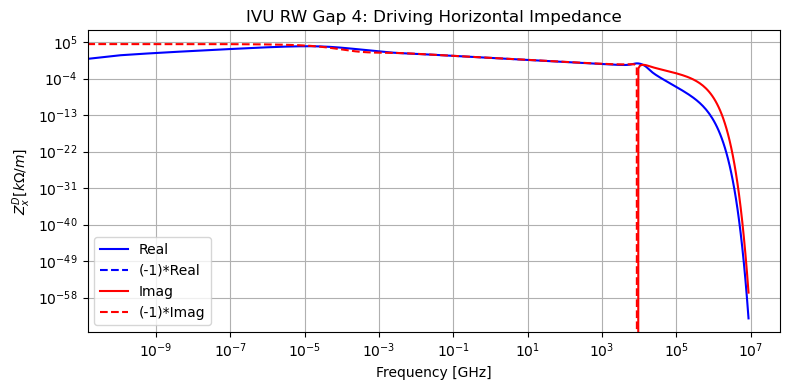

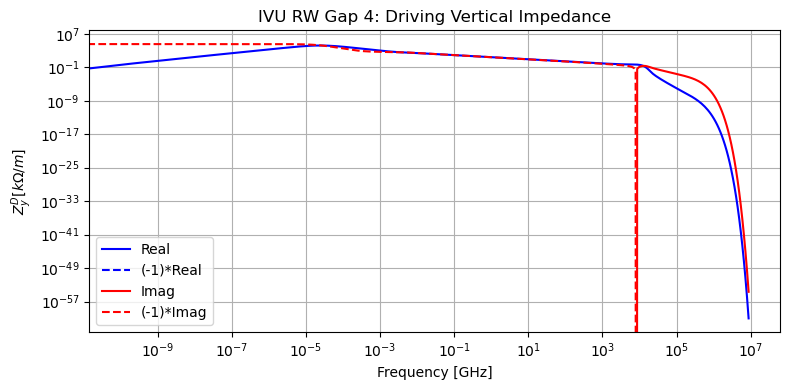

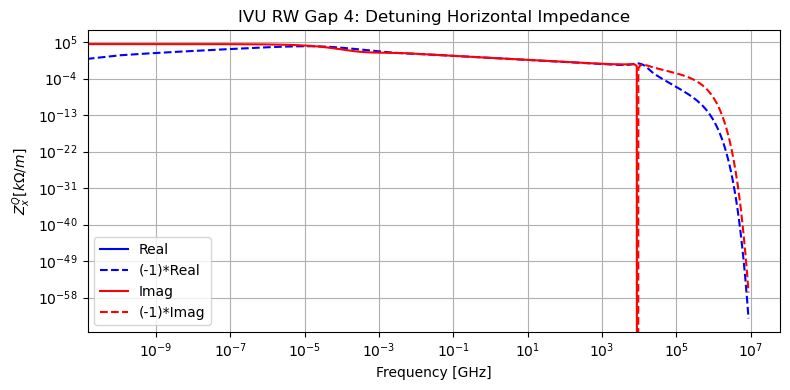

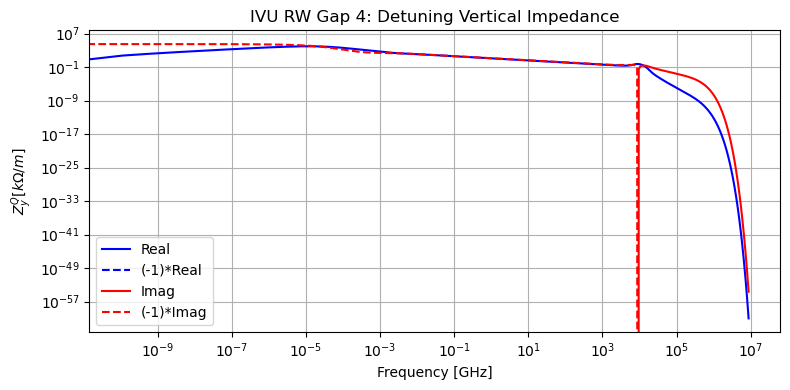

In [139]:
props = ['Zdx', 'Zdy', 'Zqx', 'Zqy']
utils.plot_el(els[0], props=props, logx=True, logy=True, show=True)
# props = [p.replace('Z', 'W') for p in props]
# utils.plot_el(els[0], props=props, logx=True, logy=True, show=True)

Comparing w/ and w/o vacuum layer

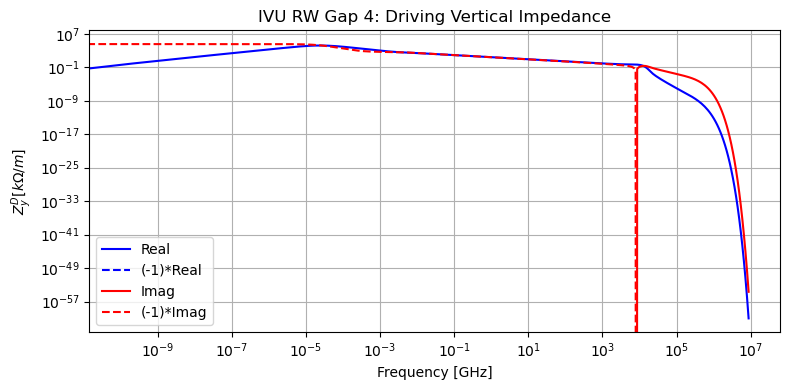

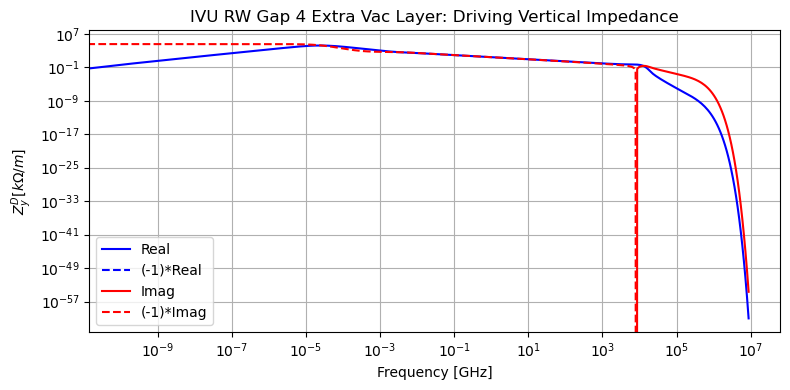

In [140]:
utils.plot_el(els[0], props='Zdy', logx=True, logy=True, show=True)
utils.plot_el(els[3], props='Zdy', logx=True, logy=True, show=True)

*Here it doesn't seem to change much, let's see in the kick factors*

### Save elements

In [136]:
for el in els:
    el.save(overwrite=True)